# Кластеризация методом DBSCAN — Распознавание активности человека

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** — алгоритм кластеризации, основанный на плотности распределения точек в пространстве признаков. 

В отличие от KMeans, DBSCAN не требует заранее задавать количество кластеров — он определяет их автоматически, основываясь на двух параметрах: **eps** (радиус окрестности) и **min_samples** (минимальное число точек в окрестности для формирования «ядра» кластера). Алгоритм способен находить кластеры произвольной формы и автоматически выделять **шумовые точки (выбросы)**, которые не принадлежат ни одному кластеру.

**HDBSCAN (Hierarchical DBSCAN)** — адаптивная версия DBSCAN, которая не требует параметра eps. Вместо фиксированного радиуса алгоритм строит иерархию кластеров при разных уровнях плотности и автоматически выбирает наиболее устойчивые. 



## Импорт библиотек

In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, HDBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.model_selection import ParameterGrid
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("Все библиотеки успешно импортированы!")

Все библиотеки успешно импортированы!


## Описание датасета

https://www.kaggle.com/datasets/vijayuv/onlineretail

### Краткое описание датасета

**Online Retail Dataset** содержит все транзакции онлайн-магазина подарков и сувениров 
(Великобритания) за период с 01.12.2010 по 09.12.2011. Многие клиенты — оптовые покупатели.

### Признаки датасета:

| Признак | Описание |
|---------|----------|
| **InvoiceNo** | Номер счёта-фактуры (уникальный для каждой транзакции, «C» = отмена) |
| **StockCode** | Код товара (уникальный для каждого товара) |
| **Description** | Текстовое описание товара |
| **Quantity** | Количество единиц товара в транзакции |
| **InvoiceDate** | Дата и время транзакции |
| **UnitPrice** | Цена за единицу товара (фунты стерлингов) |
| **CustomerID** | Уникальный идентификатор клиента |
| **Country** | Страна клиента |

Из транзакционных данных мы построим **RFM-признаки** (Recency, Frequency, Monetary) для 
каждого клиента и выполним кластеризацию по этим признакам.

In [3]:
df = pd.read_csv('/kaggle/input/datasets/vijayuv/onlineretail/OnlineRetail.csv', encoding='latin1')

print("=" * 60)
print("ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("=" * 60)
print(f"\nРазмер: {df.shape[0]:,} строк, {df.shape[1]} столбцов")
print(f"Столбцы: {list(df.columns)}")

print("\n" + "=" * 60)
print("ПЕРВЫЕ 10 СТРОК")
print("=" * 60)
df.head(10)

ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ

Размер: 541,909 строк, 8 столбцов
Столбцы: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

ПЕРВЫЕ 10 СТРОК


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [4]:
print("=" * 60)
print("ТИПЫ ДАННЫХ И ПРОПУСКИ")
print("=" * 60)
print(df.dtypes)

print(f"\nПропуски:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Пропуски': missing, '%': missing_pct})[missing > 0])

print(f"\nДубликаты: {df.duplicated().sum()}")

print("\n" + "=" * 60)
print("СТАТИСТИЧЕСКОЕ ОПИСАНИЕ")
print("=" * 60)
df.describe().round(2)

ТИПЫ ДАННЫХ И ПРОПУСКИ
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Пропуски:
             Пропуски      %
Description      1454   0.27
CustomerID     135080  24.93

Дубликаты: 5268

СТАТИСТИЧЕСКОЕ ОПИСАНИЕ


,Quantity,UnitPrice,CustomerID
count,541909.00,541909.00,406829.00
mean,9.55,4.61,15287.69
std,218.08,96.76,1713.60
min,-80995.00,-11062.06,12346.00
25%,1.00,1.25,13953.00
50%,3.00,2.08,15152.00
75%,10.00,4.13,16791.00
max,80995.00,38970.00,18287.00


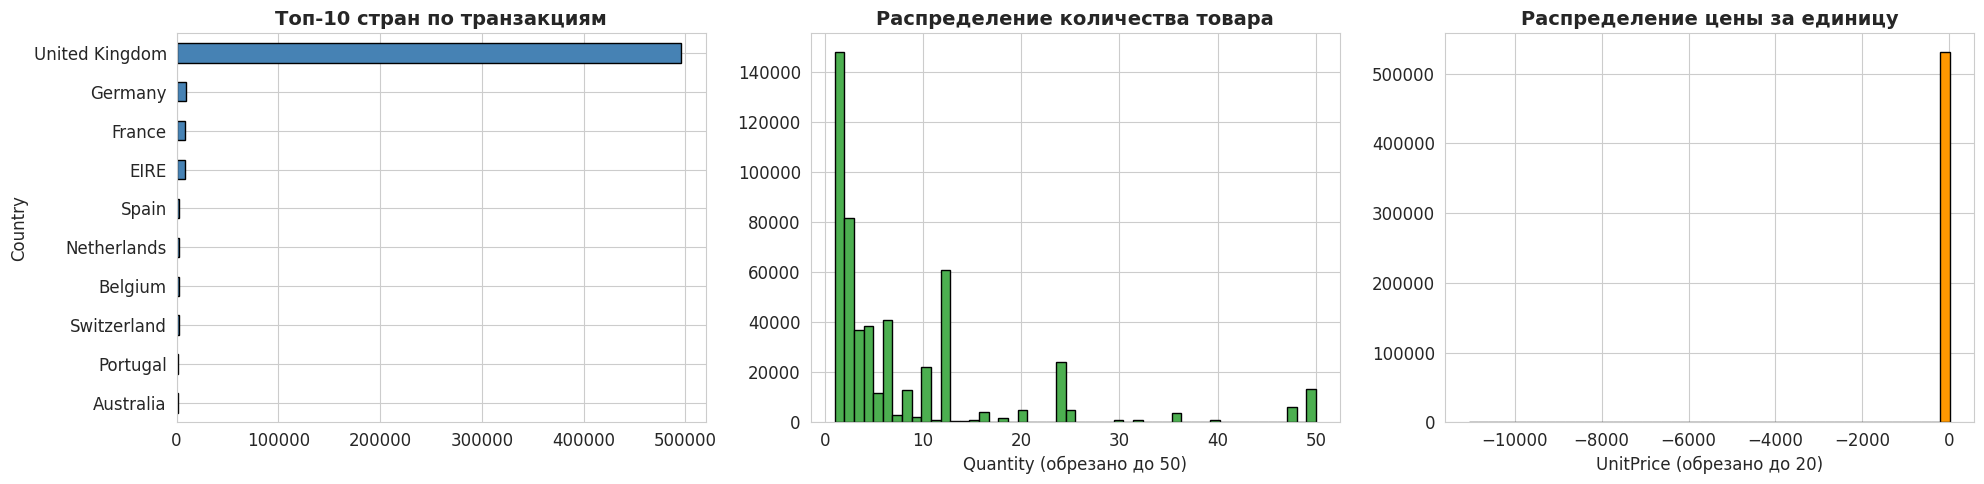

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Топ-10 стран
top_countries = df['Country'].value_counts().head(10)
top_countries.plot(kind='barh', color='steelblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Топ-10 стран по транзакциям', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# Распределение количества
df_pos = df[df['Quantity'] > 0]
axes[1].hist(df_pos['Quantity'].clip(upper=50), bins=50, color='#4CAF50', edgecolor='black')
axes[1].set_title('Распределение количества товара', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Quantity (обрезано до 50)')

# Распределение цены
axes[2].hist(df_pos['UnitPrice'].clip(upper=20), bins=50, color='#FF9800', edgecolor='black')
axes[2].set_title('Распределение цены за единицу', fontsize=14, fontweight='bold')
axes[2].set_xlabel('UnitPrice (обрезано до 20)')

plt.tight_layout()
plt.show()

## Предварительная обработка датасета

Из транзакционных данных строим **RFM-таблицу** (одна строка = один клиент):
- **Recency** — сколько дней прошло с последней покупки
- **Frequency** — сколько покупок совершил клиент
- **Monetary** — сколько всего потратил клиент
- **AvgBasket** — средний чек
- **UniqueItems** — сколько разных товаров покупал

In [8]:
df_clean = df.copy()

# Удаляем строки без CustomerID
print(f"Строк без CustomerID: {df_clean['CustomerID'].isna().sum()}")
df_clean = df_clean.dropna(subset=['CustomerID'])

# Приводим CustomerID к int
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# Парсим дату
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], errors='coerce')
df_clean = df_clean.dropna(subset=['InvoiceDate'])

# Удаляем отменённые заказы (начинаются с 'C')
df_clean['InvoiceNo'] = df_clean['InvoiceNo'].astype(str)
cancelled = df_clean['InvoiceNo'].str.startswith('C').sum()
print(f"Отменённых заказов: {cancelled}")
df_clean = df_clean[~df_clean['InvoiceNo'].str.startswith('C')]

# Удаляем строки с отрицательными значениями
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# Общая сумма по строке
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"\nРазмер после очистки: {df_clean.shape}")
print(f"Уникальных клиентов: {df_clean['CustomerID'].nunique()}")

Строк без CustomerID: 135080
Отменённых заказов: 8905

Размер после очистки: (397884, 9)
Уникальных клиентов: 4338


In [9]:
# Построение RFM-таблицы
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Референсная дата: {reference_date}")

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,   # Recency
    'InvoiceNo': 'nunique',                                      # Frequency
    'TotalPrice': 'sum',                                         # Monetary
    'StockCode': 'nunique'                                       # UniqueItems
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'UniqueItems']

# Средний чек
monetary_per_invoice = df_clean.groupby(['CustomerID', 'InvoiceNo'])['TotalPrice'].sum().reset_index()
avg_basket = monetary_per_invoice.groupby('CustomerID')['TotalPrice'].mean().reset_index()
avg_basket.columns = ['CustomerID', 'AvgBasket']

rfm = rfm.merge(avg_basket, on='CustomerID')

print(f"\nRFM-таблица: {rfm.shape}")
print(f"\nПервые 10 строк:")
rfm.head(10)

Референсная дата: 2011-12-10 12:50:00

RFM-таблица: (4338, 6)

Первые 10 строк:


,CustomerID,Recency,Frequency,Monetary,UniqueItems,AvgBasket
0,12346,326,1,77183.60,1,77183.600000
1,12347,2,7,4310.00,103,615.714286
2,12348,75,4,1797.24,22,449.310000
3,12349,19,1,1757.55,73,1757.550000
4,12350,310,1,334.40,17,334.400000
5,12352,36,8,2506.04,59,313.255000
6,12353,204,1,89.00,4,89.000000
7,12354,232,1,1079.40,58,1079.400000
8,12355,214,1,459.40,13,459.400000
9,12356,23,3,2811.43,53,937.143333


In [10]:
print("=" * 60)
print("СТАТИСТИКА RFM")
print("=" * 60)
rfm[['Recency', 'Frequency', 'Monetary', 'AvgBasket', 'UniqueItems']].describe().round(2)

СТАТИСТИКА RFM


,Recency,Frequency,Monetary,AvgBasket,UniqueItems
count,4338.00,4338.00,4338.00,4338.00,4338.00
mean,92.54,4.27,2054.27,419.17,61.50
std,100.01,7.70,8989.23,1796.54,85.37
min,1.00,1.00,3.75,3.45,1.00
25%,18.00,1.00,307.41,178.62,16.00
50%,51.00,2.00,674.48,293.90,35.00
75%,142.00,5.00,1661.74,430.11,77.00
max,374.00,209.00,280206.02,84236.25,1787.00


In [11]:
# Удаление выбросов (верхние 1% по Monetary и AvgBasket)
q99_monetary = rfm['Monetary'].quantile(0.99)
q99_basket = rfm['AvgBasket'].quantile(0.99)

before = len(rfm)
rfm = rfm[(rfm['Monetary'] <= q99_monetary) & (rfm['AvgBasket'] <= q99_basket)]
print(f"Удалено выбросов (top 1%): {before - len(rfm)}")
print(f"Итоговый размер: {rfm.shape}")

# Признаки для кластеризации
feature_cols = ['Recency', 'Frequency', 'Monetary', 'AvgBasket', 'UniqueItems']
df_features = rfm[feature_cols].copy()

print(f"\nПризнаки: {feature_cols}")
df_features.describe().round(2)

Удалено выбросов (top 1%): 69
Итоговый размер: (4269, 6)

Признаки: ['Recency', 'Frequency', 'Monetary', 'AvgBasket', 'UniqueItems']


,Recency,Frequency,Monetary,AvgBasket,UniqueItems
count,4269.00,4269.00,4269.00,4269.00,4269.00
mean,93.22,3.88,1384.98,345.19,58.68
std,100.14,4.91,2067.22,261.13,67.95
min,1.00,1.00,3.75,3.45,1.00
25%,18.00,1.00,305.10,177.85,16.00
50%,51.00,2.00,658.64,289.24,35.00
75%,144.00,5.00,1589.82,420.60,77.00
max,374.00,93.00,19824.05,2027.86,819.00


In [12]:
# Масштабирование
scaler = StandardScaler()
X_scaled_full = scaler.fit_transform(df_features)

print("Масштабирование выполнено (StandardScaler)!")

# PCA для кластеризации (снижаем размерность, убираем корреляции)
pca_model = PCA(n_components=0.95, random_state=42)
X_pca_reduced = pca_model.fit_transform(X_scaled_full)
print(f"\nPCA для кластеризации: {X_pca_reduced.shape[1]} компонент "
      f"({pca_model.explained_variance_ratio_.sum()*100:.1f}% дисперсии)")

# PCA 2D для визуализации
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled_full)
print(f"PCA для визуализации: 2 компоненты "
      f"({pca_2d.explained_variance_ratio_.sum()*100:.1f}% дисперсии)")

# DBSCAN работает на PCA-пространстве
X_scaled = X_pca_reduced
X_pca = X_pca_2d

print(f"\nДанные для кластеризации: {X_scaled.shape}")

Масштабирование выполнено (StandardScaler)!

PCA для кластеризации: 4 компонент (97.5% дисперсии)
PCA для визуализации: 2 компоненты (72.7% дисперсии)

Данные для кластеризации: (4269, 4)


## Тепловая карта корреляций (Heatmap)

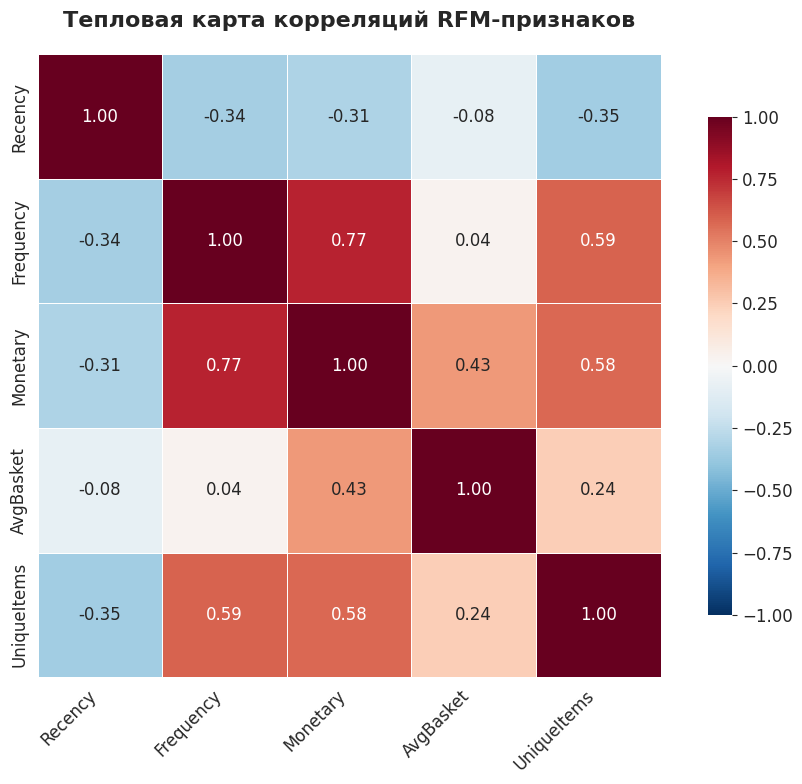

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))

correlation_matrix = df_features.corr()

sns.heatmap(
    correlation_matrix, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1, ax=ax
)
ax.set_title('Тепловая карта корреляций RFM-признаков',
             fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
corr_pairs = []
cols = correlation_matrix.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        corr_pairs.append({
            'Признак 1': cols[i],
            'Признак 2': cols[j],
            'Корреляция': correlation_matrix.iloc[i, j]
        })

corr_pairs_df = pd.DataFrame(corr_pairs)
corr_pairs_df['|Корреляция|'] = corr_pairs_df['Корреляция'].abs()
corr_pairs_df = corr_pairs_df.sort_values('|Корреляция|', ascending=False).reset_index(drop=True)
corr_pairs_df.index += 1

print("=" * 70)
print("РЕЙТИНГ ПАР ПРИЗНАКОВ ПО СИЛЕ КОРРЕЛЯЦИИ")
print("=" * 70)
for _, row in corr_pairs_df.iterrows():
    strength = "сильная" if row['|Корреляция|'] >= 0.7 else "средняя" if row['|Корреляция|'] >= 0.4 else "слабая"
    direction = "+" if row['Корреляция'] > 0 else "-"
    print(f"  {row['Признак 1']:<15} <-> {row['Признак 2']:<15} r = {row['Корреляция']:+.4f} ({strength}, {direction})")

РЕЙТИНГ ПАР ПРИЗНАКОВ ПО СИЛЕ КОРРЕЛЯЦИИ
  Frequency       <-> Monetary        r = +0.7720 (сильная, +)
  Frequency       <-> UniqueItems     r = +0.5862 (средняя, +)
  Monetary        <-> UniqueItems     r = +0.5765 (средняя, +)
  Monetary        <-> AvgBasket       r = +0.4337 (средняя, +)
  Recency         <-> UniqueItems     r = -0.3474 (слабая, -)
  Recency         <-> Frequency       r = -0.3404 (слабая, -)
  Recency         <-> Monetary        r = -0.3112 (слабая, -)
  AvgBasket       <-> UniqueItems     r = +0.2435 (слабая, +)
  Recency         <-> AvgBasket       r = -0.0797 (слабая, -)
  Frequency       <-> AvgBasket       r = +0.0357 (слабая, +)


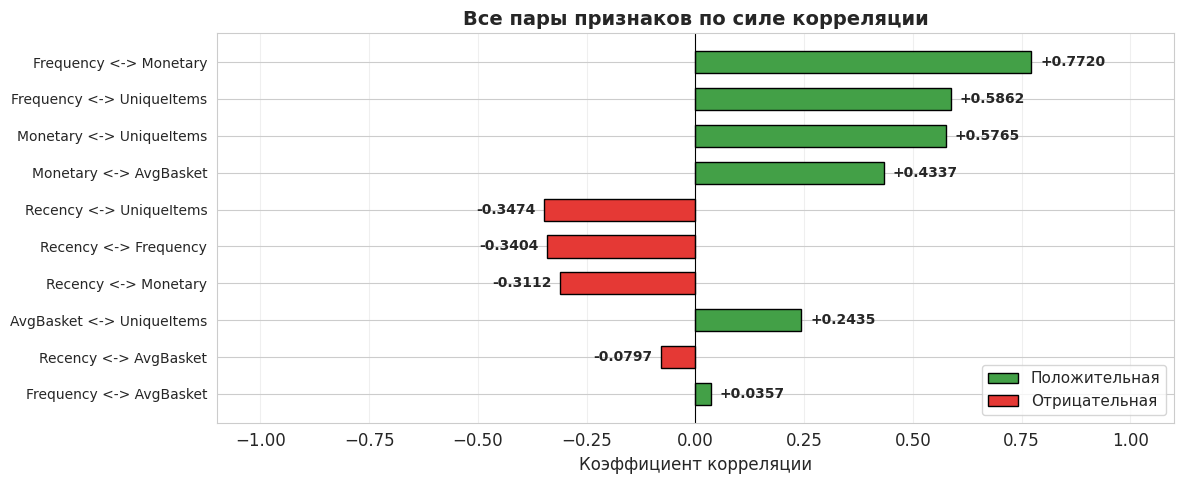

In [15]:
top_n = len(corr_pairs_df)
fig, ax = plt.subplots(figsize=(12, 5))

pair_labels = [f"{row['Признак 1']} <-> {row['Признак 2']}" for _, row in corr_pairs_df.iterrows()]
values = corr_pairs_df['Корреляция'].values
colors_bar = ['#E53935' if v < 0 else '#43A047' for v in values]

bars = ax.barh(range(top_n), values, color=colors_bar, edgecolor='black', height=0.6)
for i, (bar, v) in enumerate(zip(bars, values)):
    offset = 0.02 if v >= 0 else -0.02
    ha = 'left' if v >= 0 else 'right'
    ax.text(v + offset, i, f'{v:+.4f}', va='center', ha=ha, fontweight='bold', fontsize=10)

ax.set_yticks(range(top_n))
ax.set_yticklabels(pair_labels, fontsize=10)
ax.set_xlabel('Коэффициент корреляции', fontsize=12)
ax.set_title('Все пары признаков по силе корреляции', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', lw=0.8)
ax.set_xlim(-1.1, 1.1)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

legend_elements = [Patch(facecolor='#43A047', edgecolor='black', label='Положительная'),
                   Patch(facecolor='#E53935', edgecolor='black', label='Отрицательная')]
ax.legend(handles=legend_elements, fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

## Подбор гиперпараметров DBSCAN

In [203]:
param_grid = {
    'eps': [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0],
    'min_samples': [3, 5, 10, 15, 20],
    'metric': ['manhattan'],
    'algorithm': ['ball_tree', 'kd_tree']
}

all_params = list(ParameterGrid(param_grid))
cv = 3

print("=" * 60)
print("ПОДБОР ГИПЕРПАРАМЕТРОВ DBSCAN (cv=3)")
print("=" * 60)
print(f"\nКластеризация в PCA-пространстве ({X_scaled.shape[1]} компонент)")
print(f"\nСетка параметров:")
for key, values in param_grid.items():
    print(f"  {key}: {values}")
print(f"\nВсего комбинаций: {len(all_params)}")
print(f"С учётом cv=3: {len(all_params) * 3} обучений")
print("\nПеребор начат...")

results = []

for idx, params in enumerate(all_params):
    sil_scores, ch_scores, db_scores = [], [], []
    n_clusters_list, noise_pct_list, times_list = [], [], []

    for seed in range(cv):
        np.random.seed(seed * 42 + 7)
        sub_idx = np.random.choice(len(X_scaled), size=int(len(X_scaled) * 0.8), replace=False)
        X_sub = X_scaled[sub_idx]

        try:
            t0 = time.time()
            model = DBSCAN(
                eps=params['eps'],
                min_samples=params['min_samples'],
                metric=params['metric'],
                algorithm=params['algorithm'],
                n_jobs=-1
            )
            labels = model.fit_predict(X_sub)
            elapsed = time.time() - t0

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            noise_pct = (labels == -1).sum() / len(labels) * 100
            n_clusters_list.append(n_clusters)
            noise_pct_list.append(noise_pct)
            times_list.append(elapsed)

            non_noise = labels != -1
            n_unique = len(np.unique(labels[non_noise])) if non_noise.sum() > 0 else 0
            if n_unique >= 2:
                sil_scores.append(silhouette_score(X_sub[non_noise], labels[non_noise],
                                                    sample_size=min(3000, non_noise.sum())))
                ch_scores.append(calinski_harabasz_score(X_sub[non_noise], labels[non_noise]))
                db_scores.append(davies_bouldin_score(X_sub[non_noise], labels[non_noise]))

        except Exception:
            times_list.append(np.nan)
            continue

    results.append({
        'params': params,
        'eps': params['eps'],
        'min_samples': params['min_samples'],
        'metric': params['metric'],
        'algorithm': params['algorithm'],
        'mean_n_clusters': np.mean(n_clusters_list) if n_clusters_list else 0,
        'mean_noise_pct': np.mean(noise_pct_list) if noise_pct_list else 100,
        'mean_silhouette': np.mean(sil_scores) if sil_scores else np.nan,
        'std_silhouette': np.std(sil_scores) if sil_scores else np.nan,
        'mean_calinski_harabasz': np.mean(ch_scores) if ch_scores else np.nan,
        'mean_davies_bouldin': np.mean(db_scores) if db_scores else np.nan,
        'mean_time': np.nanmean(times_list) if times_list else np.nan
    })

    if (idx + 1) % 10 == 0:
        print(f"  Обработано {idx + 1}/{len(all_params)}...")

results_df = pd.DataFrame(results)
print(f"\nПеребор завершён! Всего комбинаций: {len(results_df)}")

ПОДБОР ГИПЕРПАРАМЕТРОВ DBSCAN (cv=3)

Кластеризация в PCA-пространстве (4 компонент)

Сетка параметров:
  eps: [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
  min_samples: [3, 5, 10, 15, 20]
  metric: ['manhattan']
  algorithm: ['ball_tree', 'kd_tree']

Всего комбинаций: 70
С учётом cv=3: 210 обучений

Перебор начат...
  Обработано 10/70...
  Обработано 20/70...
  Обработано 30/70...
  Обработано 40/70...
  Обработано 50/70...
  Обработано 60/70...
  Обработано 70/70...

Перебор завершён! Всего комбинаций: 70


In [204]:
# Фильтрация: шум <= 25%
before = len(results_df)
results_df = results_df[
    (results_df['mean_noise_pct'] <= 25)
].copy()

results_df = results_df.sort_values('mean_silhouette', ascending=False, na_position='last').reset_index(drop=True)
results_df.index += 1

In [205]:
best_row = results_df.iloc[0]

print("=" * 70)
print("ЛУЧШАЯ КОМБИНАЦИЯ ПАРАМЕТРОВ")
print("=" * 70)
print(f"\n  eps:          {best_row['eps']}")
print(f"  min_samples:  {best_row['min_samples']}")
print(f"  metric:       {best_row['metric']}")
print(f"  algorithm:    {best_row['algorithm']}")
print(f"\n  Silhouette:        {best_row['mean_silhouette']:.4f} +/- {best_row['std_silhouette']:.4f}")
print(f"  Calinski-Harabasz: {best_row['mean_calinski_harabasz']:.2f}")
print(f"  Davies-Bouldin:    {best_row['mean_davies_bouldin']:.4f}")
print(f"  Кластеров:         {best_row['mean_n_clusters']:.0f}")
print(f"  Шум:               {best_row['mean_noise_pct']:.1f}%")

ЛУЧШАЯ КОМБИНАЦИЯ ПАРАМЕТРОВ

  eps:          2.0
  min_samples:  3
  metric:       manhattan
  algorithm:    ball_tree

  Silhouette:        0.6897 +/- 0.0747
  Calinski-Harabasz: 82.53
  Davies-Bouldin:    0.3399
  Кластеров:         3
  Шум:               1.1%


In [206]:
print("=" * 70)
print("ВЛИЯНИЕ ПАРАМЕТРА: eps")
print("=" * 70)
eps_s = results_df.groupby('eps').agg({
    'mean_silhouette': ['mean', 'max'],
    'mean_n_clusters': 'mean',
    'mean_noise_pct': 'mean'
}).round(4)
eps_s.columns = ['Sil (ср)', 'Sil (макс)', 'Кластеров (ср)', 'Шум % (ср)']
print(eps_s)

print("\n" + "=" * 70)
print("ВЛИЯНИЕ ПАРАМЕТРА: min_samples")
print("=" * 70)
ms_s = results_df.groupby('min_samples').agg({
    'mean_silhouette': ['mean', 'max'],
    'mean_n_clusters': 'mean',
    'mean_noise_pct': 'mean'
}).round(4)
ms_s.columns = ['Sil (ср)', 'Sil (макс)', 'Кластеров (ср)', 'Шум % (ср)']
print(ms_s)

print("\n" + "=" * 70)
print("ВЛИЯНИЕ ПАРАМЕТРА: metric")
print("=" * 70)
met_s = results_df.groupby('metric').agg({
    'mean_silhouette': ['mean', 'max'],
    'mean_n_clusters': 'mean',
    'mean_noise_pct': 'mean',
    'mean_time': 'mean'
}).round(4)
met_s.columns = ['Sil (ср)', 'Sil (макс)', 'Кластеров (ср)', 'Шум % (ср)', 'Время (ср)']
print(met_s)

print("\n" + "=" * 70)
print("ВЛИЯНИЕ ПАРАМЕТРА: algorithm")
print("=" * 70)
alg_s = results_df.groupby('algorithm').agg({
    'mean_silhouette': ['mean', 'max'],
    'mean_time': ['mean', 'min', 'max']
}).round(4)
alg_s.columns = ['Sil (ср)', 'Sil (макс)', 'Время (ср)', 'Время (мин)', 'Время (макс)']
print(alg_s)

ВЛИЯНИЕ ПАРАМЕТРА: eps
      Sil (ср)  Sil (макс)  Кластеров (ср)  Шум % (ср)
eps                                                   
0.50   -0.2576     -0.2576         29.6667     21.1518
0.75    0.2806      0.3786          5.0667     17.0874
1.00    0.4293      0.5011          3.8000     10.2255
1.25    0.4300      0.5111          3.2000      6.5905
1.50    0.5057      0.5422          2.7333      4.5505
1.75    0.5663      0.5977          1.8000      3.2367
2.00    0.6396      0.6897          1.4000      2.3387

ВЛИЯНИЕ ПАРАМЕТРА: min_samples
             Sil (ср)  Sil (макс)  Кластеров (ср)  Шум % (ср)
min_samples                                                  
3              0.3488      0.6897         10.9048      6.3348
5              0.4571      0.5356          3.8333      5.1733
10             0.4881      0.5977          1.3333      7.7273
15             0.5894      0.5894          1.0556      9.3704
20                NaN         NaN          1.0000     10.5547

ВЛИЯНИЕ ПАРАМЕТ

## Подбор гиперпараметров HDBSCAN

In [207]:
param_grid_h = {
    'min_cluster_size': [10, 20, 30, 50, 75, 100, 150],
    'min_samples': [None, 3, 5, 10, 15, 20],
    'algorithm': ['kd_tree', 'ball_tree'],
    'metric': ['manhattan'],
    'cluster_selection_method': ['eom', 'leaf']
}

all_params_h = list(ParameterGrid(param_grid_h))
cv = 3

print("=" * 60)
print("ПОДБОР ГИПЕРПАРАМЕТРОВ HDBSCAN (cv=3)")
print("=" * 60)
print(f"\nСетка параметров:")
for key, values in param_grid_h.items():
    print(f"  {key}: {values}")
print(f"\nВсего комбинаций: {len(all_params_h)}")
print(f"С учётом cv=3: {len(all_params_h) * 3} обучений")
print("\nПеребор начат...")

results_h = []

for idx, params in enumerate(all_params_h):
    sil_scores, ch_scores, db_scores = [], [], []
    n_clusters_list, noise_pct_list, times_list = [], [], []

    for seed in range(cv):
        np.random.seed(seed * 42 + 7)
        sub_idx = np.random.choice(len(X_scaled), size=int(len(X_scaled) * 0.8), replace=False)
        X_sub = X_scaled[sub_idx]

        try:
            t0 = time.time()
            model = HDBSCAN(
                min_cluster_size=params['min_cluster_size'],
                min_samples=params['min_samples'],
                metric=params['metric'],
                cluster_selection_method=params['cluster_selection_method'],
                n_jobs=-1
            )
            labels = model.fit_predict(X_sub)
            elapsed = time.time() - t0

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            noise_pct = (labels == -1).sum() / len(labels) * 100
            n_clusters_list.append(n_clusters)
            noise_pct_list.append(noise_pct)
            times_list.append(elapsed)

            non_noise = labels != -1
            n_unique = len(np.unique(labels[non_noise])) if non_noise.sum() > 0 else 0
            if n_unique >= 2:
                sil_scores.append(silhouette_score(X_sub[non_noise], labels[non_noise],
                                                    sample_size=min(3000, non_noise.sum())))
                ch_scores.append(calinski_harabasz_score(X_sub[non_noise], labels[non_noise]))
                db_scores.append(davies_bouldin_score(X_sub[non_noise], labels[non_noise]))

        except Exception:
            times_list.append(np.nan)
            continue

    results_h.append({
        'params': params,
        'min_cluster_size': params['min_cluster_size'],
        'min_samples': params['min_samples'],
        'metric': params['metric'],
        'cluster_selection_method': params['cluster_selection_method'],
        'mean_n_clusters': np.mean(n_clusters_list) if n_clusters_list else 0,
        'mean_noise_pct': np.mean(noise_pct_list) if noise_pct_list else 100,
        'mean_silhouette': np.mean(sil_scores) if sil_scores else np.nan,
        'std_silhouette': np.std(sil_scores) if sil_scores else np.nan,
        'mean_calinski_harabasz': np.mean(ch_scores) if ch_scores else np.nan,
        'mean_davies_bouldin': np.mean(db_scores) if db_scores else np.nan,
        'mean_time': np.nanmean(times_list) if times_list else np.nan
    })

    if (idx + 1) % 10 == 0:
        print(f"  Обработано {idx + 1}/{len(all_params_h)}...")

results_h_df = pd.DataFrame(results_h)
print(f"\nПеребор завершён! Всего комбинаций: {len(results_h_df)}")

ПОДБОР ГИПЕРПАРАМЕТРОВ HDBSCAN (cv=3)

Сетка параметров:
  min_cluster_size: [10, 20, 30, 50, 75, 100, 150]
  min_samples: [None, 3, 5, 10, 15, 20]
  algorithm: ['kd_tree', 'ball_tree']
  metric: ['manhattan']
  cluster_selection_method: ['eom', 'leaf']

Всего комбинаций: 168
С учётом cv=3: 504 обучений

Перебор начат...
  Обработано 10/168...
  Обработано 20/168...
  Обработано 30/168...
  Обработано 40/168...
  Обработано 50/168...
  Обработано 60/168...
  Обработано 70/168...
  Обработано 80/168...
  Обработано 90/168...
  Обработано 100/168...
  Обработано 110/168...
  Обработано 120/168...
  Обработано 130/168...
  Обработано 140/168...
  Обработано 150/168...
  Обработано 160/168...

Перебор завершён! Всего комбинаций: 168


In [230]:
# Фильтрация: шум <= 25%
before_h = len(results_h_df)
results_h_df = results_h_df[
    (results_h_df['mean_noise_pct'] <= 25)
].copy()

results_h_df = results_h_df.sort_values('mean_silhouette', ascending=False, na_position='last').reset_index(drop=True)
results_h_df.index += 1

In [231]:
best_row_h = results_h_df.iloc[0]

print("=" * 70)
print("ЛУЧШАЯ КОМБИНАЦИЯ ПАРАМЕТРОВ HDBSCAN")
print("=" * 70)
print(f"\n  min_cluster_size:          {best_row_h['min_cluster_size']}")
print(f"  min_samples:               {best_row_h['min_samples']}")
print(f"  metric:                    {best_row_h['metric']}")
print(f"  cluster_selection_method:  {best_row_h['cluster_selection_method']}")
print(f"\n  Silhouette:        {best_row_h['mean_silhouette']:.4f} +/- {best_row_h['std_silhouette']:.4f}")
print(f"  Calinski-Harabasz: {best_row_h['mean_calinski_harabasz']:.2f}")
print(f"  Davies-Bouldin:    {best_row_h['mean_davies_bouldin']:.4f}")
print(f"  Кластеров:         {best_row_h['mean_n_clusters']:.0f}")
print(f"  Шум:               {best_row_h['mean_noise_pct']:.1f}%")

ЛУЧШАЯ КОМБИНАЦИЯ ПАРАМЕТРОВ HDBSCAN

  min_cluster_size:          10
  min_samples:               3.0
  metric:                    manhattan
  cluster_selection_method:  eom

  Silhouette:        0.4947 +/- 0.0717
  Calinski-Harabasz: 129.54
  Davies-Bouldin:    0.5411
  Кластеров:         4
  Шум:               8.6%


In [232]:
print("=" * 70)
print("ВЛИЯНИЕ ПАРАМЕТРА: min_cluster_size")
print("=" * 70)
mcs_s = results_h_df.groupby('min_cluster_size').agg({
    'mean_silhouette': ['mean', 'max'],
    'mean_n_clusters': 'mean',
    'mean_noise_pct': 'mean'
}).round(4)
mcs_s.columns = ['Sil (ср)', 'Sil (макс)', 'Кластеров (ср)', 'Шум % (ср)']
print(mcs_s)

print("\n" + "=" * 70)
print("ВЛИЯНИЕ ПАРАМЕТРА: min_samples")
print("=" * 70)
ms_h_s = results_h_df.groupby('min_samples').agg({
    'mean_silhouette': ['mean', 'max'],
    'mean_n_clusters': 'mean',
    'mean_noise_pct': 'mean'
}).round(4)
ms_h_s.columns = ['Sil (ср)', 'Sil (макс)', 'Кластеров (ср)', 'Шум % (ср)']
print(ms_h_s)

print("\n" + "=" * 70)
print("ВЛИЯНИЕ ПАРАМЕТРА: metric")
print("=" * 70)
met_h_s = results_h_df.groupby('metric').agg({
    'mean_silhouette': ['mean', 'max'],
    'mean_n_clusters': 'mean',
    'mean_noise_pct': 'mean',
    'mean_time': 'mean'
}).round(4)
met_h_s.columns = ['Sil (ср)', 'Sil (макс)', 'Кластеров (ср)', 'Шум % (ср)', 'Время (ср)']
print(met_h_s)

print("\n" + "=" * 70)
print("ВЛИЯНИЕ ПАРАМЕТРА: cluster_selection_method")
print("=" * 70)
csm_s = results_h_df.groupby('cluster_selection_method').agg({
    'mean_silhouette': ['mean', 'max'],
    'mean_n_clusters': 'mean',
    'mean_noise_pct': 'mean'
}).round(4)
csm_s.columns = ['Sil (ср)', 'Sil (макс)', 'Кластеров (ср)', 'Шум % (ср)']
print(csm_s)

ВЛИЯНИЕ ПАРАМЕТРА: min_cluster_size
                  Sil (ср)  Sil (макс)  Кластеров (ср)  Шум % (ср)
min_cluster_size                                                  
10                  0.4947      0.4947          3.6667      8.6481

ВЛИЯНИЕ ПАРАМЕТРА: min_samples
             Sil (ср)  Sil (макс)  Кластеров (ср)  Шум % (ср)
min_samples                                                  
3.0            0.4947      0.4947          3.6667      8.6481

ВЛИЯНИЕ ПАРАМЕТРА: metric
           Sil (ср)  Sil (макс)  Кластеров (ср)  Шум % (ср)  Время (ср)
metric                                                                 
manhattan    0.4947      0.4947          3.6667      8.6481      0.1378

ВЛИЯНИЕ ПАРАМЕТРА: cluster_selection_method
                          Sil (ср)  Sil (макс)  Кластеров (ср)  Шум % (ср)
cluster_selection_method                                                  
eom                         0.4947      0.4947          3.6667      8.6481


## Обучение лучших моделей

In [233]:
# === ЛУЧШИЙ DBSCAN ===
best_params_db = results_df.iloc[0]['params']

print("=" * 60)
print("ОБУЧЕНИЕ ЛУЧШЕГО DBSCAN")
print("=" * 60)
for k, v in best_params_db.items():
    print(f"  {k}: {v}")

t0 = time.time()
model_db = DBSCAN(
    eps=best_params_db['eps'],
    min_samples=best_params_db['min_samples'],
    metric=best_params_db['metric'],
    algorithm=best_params_db['algorithm'],
    n_jobs=-1
)
labels_db = model_db.fit_predict(X_scaled)
time_db = time.time() - t0

n_cl_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db = (labels_db == -1).sum()
print(f"\n  Кластеров: {n_cl_db}, Шум: {n_noise_db} ({n_noise_db/len(labels_db)*100:.1f}%), Время: {time_db:.4f}с")

# === ЛУЧШИЙ HDBSCAN ===
best_params_hdb = results_h_df.iloc[0]['params']

print("\n" + "=" * 60)
print("ОБУЧЕНИЕ ЛУЧШЕГО HDBSCAN")
print("=" * 60)
for k, v in best_params_hdb.items():
    print(f"  {k}: {v}")

t0 = time.time()
model_hdb = HDBSCAN(
    min_cluster_size=best_params_hdb['min_cluster_size'],
    min_samples=best_params_hdb['min_samples'],
    metric=best_params_hdb['metric'],
    cluster_selection_method=best_params_hdb['cluster_selection_method'],
    n_jobs=-1
)
labels_hdb = model_hdb.fit_predict(X_scaled)
time_hdb = time.time() - t0

n_cl_hdb = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
n_noise_hdb = (labels_hdb == -1).sum()
print(f"\n  Кластеров: {n_cl_hdb}, Шум: {n_noise_hdb} ({n_noise_hdb/len(labels_hdb)*100:.1f}%), Время: {time_hdb:.4f}с")

ОБУЧЕНИЕ ЛУЧШЕГО DBSCAN
  algorithm: ball_tree
  eps: 2.0
  metric: manhattan
  min_samples: 3

  Кластеров: 4, Шум: 42 (1.0%), Время: 0.2660с

ОБУЧЕНИЕ ЛУЧШЕГО HDBSCAN
  algorithm: ball_tree
  cluster_selection_method: eom
  metric: manhattan
  min_cluster_size: 10
  min_samples: 3

  Кластеров: 63, Шум: 2538 (59.5%), Время: 0.1872с


## Графики выходных результатов

In [234]:
def calc_metrics(X, labels, name):
    non_noise = labels != -1
    n_cl = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    noise_pct = n_noise / len(labels) * 100

    if non_noise.sum() > 0 and len(np.unique(labels[non_noise])) >= 2:
        sil = silhouette_score(X[non_noise], labels[non_noise],
                                sample_size=min(3000, non_noise.sum()))
        ch = calinski_harabasz_score(X[non_noise], labels[non_noise])
        db = davies_bouldin_score(X[non_noise], labels[non_noise])
    else:
        sil, ch, db = np.nan, np.nan, np.nan

    return {
        'Модель': name,
        'Кластеров': n_cl,
        'Шум (%)': round(noise_pct, 1),
        'Silhouette (↑)': round(sil, 4) if not np.isnan(sil) else 'N/A',
        'Calinski-Harabasz (↑)': round(ch, 2) if not np.isnan(ch) else 'N/A',
        'Davies-Bouldin (↓)': round(db, 4) if not np.isnan(db) else 'N/A',
        'sil_raw': sil
    }

m_db = calc_metrics(X_scaled, labels_db, 'DBSCAN')
m_hdb = calc_metrics(X_scaled, labels_hdb, 'HDBSCAN')

comparison = pd.DataFrame([m_db, m_hdb]).drop(columns=['sil_raw'])
print("=" * 70)
print("СРАВНЕНИЕ DBSCAN vs HDBSCAN")
print("=" * 70)
print(comparison.to_string(index=False))

# Определяем победителя
sil_db = m_db['sil_raw']
sil_hdb = m_hdb['sil_raw']

if np.isnan(sil_db) and np.isnan(sil_hdb):
    winner = 'DBSCAN'
    winner_labels = labels_db
    print("\n  Обе модели без метрик, берём DBSCAN по умолчанию")
elif np.isnan(sil_db):
    winner = 'HDBSCAN'
    winner_labels = labels_hdb
elif np.isnan(sil_hdb):
    winner = 'DBSCAN'
    winner_labels = labels_db
elif sil_hdb > sil_db:
    winner = 'HDBSCAN'
    winner_labels = labels_hdb
else:
    winner = 'DBSCAN'
    winner_labels = labels_db

print(f"\n  🏆 Победитель по Silhouette Score: {winner}")

СРАВНЕНИЕ DBSCAN vs HDBSCAN
 Модель  Кластеров  Шум (%)  Silhouette (↑)  Calinski-Harabasz (↑)  Davies-Bouldin (↓)
 DBSCAN          4      1.0          0.5312                  82.87              0.5654
HDBSCAN         63     59.5          0.1183                 523.24              1.2684

  🏆 Победитель по Silhouette Score: DBSCAN


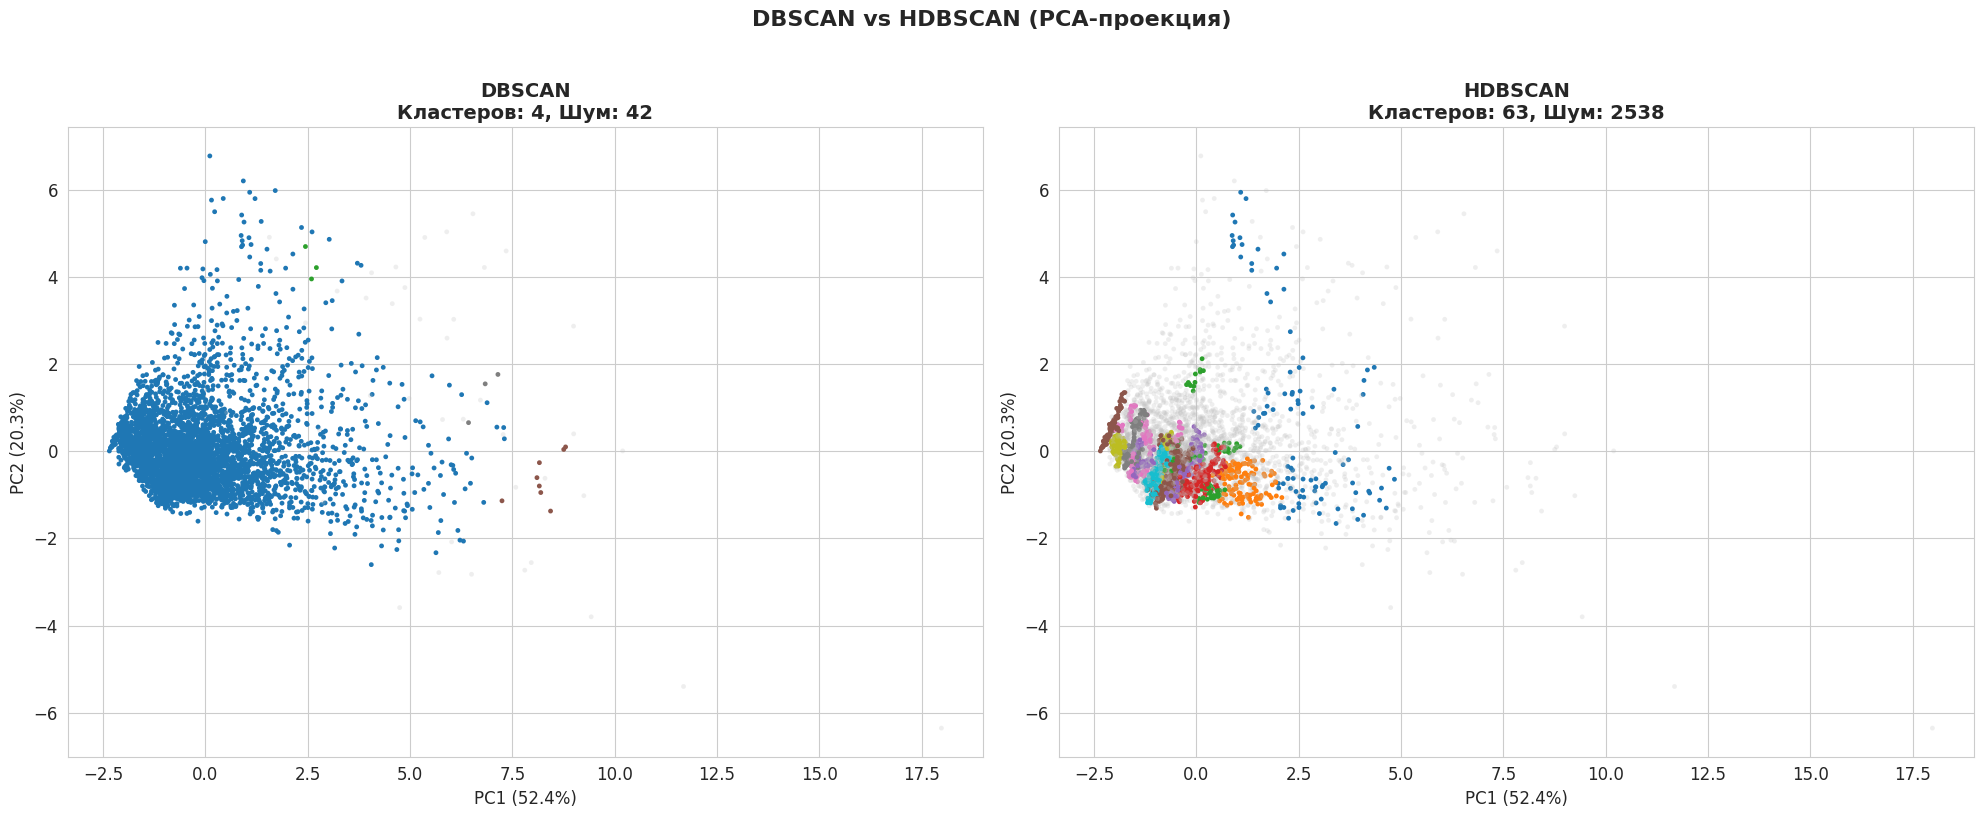

In [235]:
# PCA-визуализация обеих моделей
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, labels, title, n_cl in [
    (axes[0], labels_db, f'DBSCAN\nКластеров: {n_cl_db}, Шум: {n_noise_db}', n_cl_db),
    (axes[1], labels_hdb, f'HDBSCAN\nКластеров: {n_cl_hdb}, Шум: {n_noise_hdb}', n_cl_hdb)
]:
    unique_l = sorted(set(labels))
    cmap_v = plt.cm.tab10
    cm = {}
    ci = 0
    for lbl in unique_l:
        if lbl == -1:
            cm[lbl] = (0.75, 0.75, 0.75, 0.25)
        else:
            cm[lbl] = cmap_v(ci / max(n_cl, 1))
            ci += 1
    pc = [cm[l] for l in labels]

    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=pc, s=12, edgecolors='none')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')

plt.suptitle('DBSCAN vs HDBSCAN (PCA-проекция)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

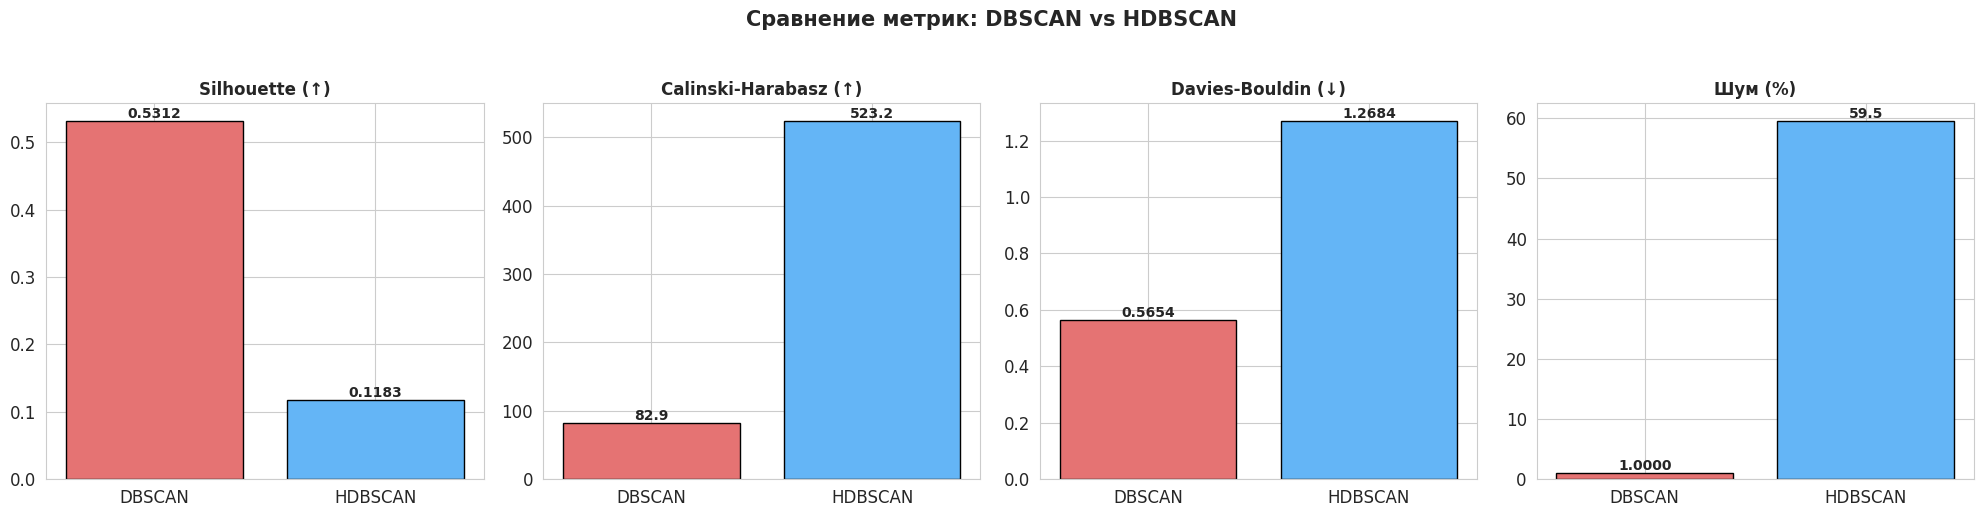

In [236]:
# Столбчатое сравнение метрик
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

metrics_compare = [
    ('Silhouette (↑)', m_db.get('sil_raw', 0), m_hdb.get('sil_raw', 0), True),
    ('Calinski-Harabasz (↑)',
     m_db['Calinski-Harabasz (↑)'] if m_db['Calinski-Harabasz (↑)'] != 'N/A' else 0,
     m_hdb['Calinski-Harabasz (↑)'] if m_hdb['Calinski-Harabasz (↑)'] != 'N/A' else 0, True),
    ('Davies-Bouldin (↓)',
     m_db['Davies-Bouldin (↓)'] if m_db['Davies-Bouldin (↓)'] != 'N/A' else 0,
     m_hdb['Davies-Bouldin (↓)'] if m_hdb['Davies-Bouldin (↓)'] != 'N/A' else 0, False),
    ('Шум (%)', m_db['Шум (%)'], m_hdb['Шум (%)'], False)
]

for ax, (title, val_db, val_hdb, higher_better) in zip(axes, metrics_compare):
    val_db = val_db if not (isinstance(val_db, float) and np.isnan(val_db)) else 0
    val_hdb = val_hdb if not (isinstance(val_hdb, float) and np.isnan(val_hdb)) else 0

    colors = ['#E57373', '#64B5F6']
    bars = ax.bar(['DBSCAN', 'HDBSCAN'], [val_db, val_hdb], color=colors, edgecolor='black')
    for bar, v in zip(bars, [val_db, val_hdb]):
        fmt = '.4f' if abs(v) < 10 else '.1f'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                f'{v:{fmt}}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Сравнение метрик: DBSCAN vs HDBSCAN',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## Интерпретация кластеров лучшей модели

In [237]:
# Используем победителя
best_labels = winner_labels
n_clusters = len(set(best_labels)) - (1 if -1 in best_labels else 0)
n_noise = (best_labels == -1).sum()

print(f"Лучшая модель: {winner}")
print(f"Кластеров: {n_clusters}, Шум: {n_noise} ({n_noise/len(best_labels)*100:.1f}%)")

df_result = df_features.copy()
df_result['Cluster'] = best_labels

print("\n" + "=" * 60)
print("ПРОФИЛИ КЛАСТЕРОВ (средние значения)")
print("=" * 60)

profile = df_result.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'AvgBasket': 'mean',
    'UniqueItems': 'mean'
}).round(1)
profile['Количество'] = df_result.groupby('Cluster').size()
profile['Доля (%)'] = (profile['Количество'] / len(df_result) * 100).round(1)
profile

Лучшая модель: DBSCAN
Кластеров: 4, Шум: 42 (1.0%)

ПРОФИЛИ КЛАСТЕРОВ (средние значения)


,Recency,Frequency,Monetary,AvgBasket,UniqueItems,Количество,Доля (%)
Cluster,,,,,,,
-1,47.4,21.2,10105.9,860.3,238.4,42,1.0
0,93.9,3.6,1256.2,338.6,56.7,4213,98.7
1,46.0,4.0,6294.4,1573.6,46.7,3,0.1
2,3.4,32.6,15865.6,494.6,175.2,8,0.2
3,4.0,20.7,16685.6,815.5,81.0,3,0.1


In [238]:
# Автоматическая интерпретация
global_means = df_features[feature_cols].mean()

segment_names = {}
segment_descriptions = {}
segment_recommendations = {}

for cl in sorted(df_result['Cluster'].unique()):
    subset = df_result[df_result['Cluster'] == cl]
    count = len(subset)

    if cl == -1:
        segment_names[-1] = "Аномальные клиенты"
        segment_descriptions[-1] = "нетипичное поведение, не вписываются ни в один сегмент"
        segment_recommendations[-1] = "индивидуальный анализ; проверка на мошенничество или ошибки"
        continue

    cl_means = subset[feature_cols].mean()
    name_parts, desc_parts, rec_parts = [], [], []

    if cl_means['Recency'] < global_means['Recency'] * 0.5:
        name_parts.append("Активные")
        desc_parts.append("покупали совсем недавно")
    elif cl_means['Recency'] > global_means['Recency'] * 1.5:
        name_parts.append("Спящие")
        desc_parts.append("давно не покупали")
        rec_parts.append("реактивационные кампании, скидки")

    if cl_means['Frequency'] > global_means['Frequency'] * 1.5:
        name_parts.append("Частые")
        desc_parts.append("покупают очень часто")
        rec_parts.append("программа лояльности, VIP-статус")
    elif cl_means['Frequency'] < global_means['Frequency'] * 0.5:
        desc_parts.append("редкие покупки")
        rec_parts.append("стимулирование повторных покупок")

    if cl_means['Monetary'] > global_means['Monetary'] * 2:
        name_parts.append("Крупные")
        desc_parts.append("очень высокие траты")
        rec_parts.append("персональный менеджер, эксклюзивные предложения")
    elif cl_means['Monetary'] < global_means['Monetary'] * 0.5:
        name_parts.append("Экономные")
        desc_parts.append("низкие траты")
        rec_parts.append("акции, бюджетные предложения")

    if cl_means['AvgBasket'] > global_means['AvgBasket'] * 1.5:
        desc_parts.append("высокий средний чек")
    if cl_means['UniqueItems'] > global_means['UniqueItems'] * 1.5:
        desc_parts.append("широкий ассортимент покупок")
        rec_parts.append("рекомендации новых категорий")

    if not name_parts:
        name_parts.append("Типичные")
    if not rec_parts:
        rec_parts.append("стандартные маркетинговые кампании")

    segment_names[cl] = " / ".join(name_parts)
    segment_descriptions[cl] = "; ".join(desc_parts) if desc_parts else "средние показатели"
    segment_recommendations[cl] = "; ".join(rec_parts)

print("=" * 70)
print(f"ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ ({winner})")
print("=" * 70)

for cl in sorted(segment_names.keys()):
    subset = df_result[df_result['Cluster'] == cl]
    count = len(subset)
    pct = count / len(df_result) * 100
    cl_label = "ШУМ" if cl == -1 else f"КЛАСТЕР {cl}"

    print(f"\n{'━' * 70}")
    print(f"  {cl_label}: «{segment_names[cl]}»")
    print(f"  {count} клиентов ({pct:.1f}%)")
    print(f"{'━' * 70}")
    print(f"  📋 Характеристика: {segment_descriptions[cl]}")
    print(f"  🎯 Рекомендации:   {segment_recommendations[cl]}")

    if cl != -1:
        cl_means = subset[feature_cols].mean()
        print(f"  📊 Recency: {cl_means['Recency']:.0f} дн | Frequency: {cl_means['Frequency']:.0f} | "
              f"Monetary: £{cl_means['Monetary']:.0f} | AvgBasket: £{cl_means['AvgBasket']:.0f}")

ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ (DBSCAN)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ШУМ: «Аномальные клиенты»
  42 клиентов (1.0%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📋 Характеристика: нетипичное поведение, не вписываются ни в один сегмент
  🎯 Рекомендации:   индивидуальный анализ; проверка на мошенничество или ошибки

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  КЛАСТЕР 0: «Типичные»
  4213 клиентов (98.7%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📋 Характеристика: средние показатели
  🎯 Рекомендации:   стандартные маркетинговые кампании
  📊 Recency: 94 дн | Frequency: 4 | Monetary: £1256 | AvgBasket: £339

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  КЛАСТЕР 1: «Активные / Крупные»
  3 клиентов (0.1%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📋 Характеристика: покупали совсем недавно; очень высокие траты; вы

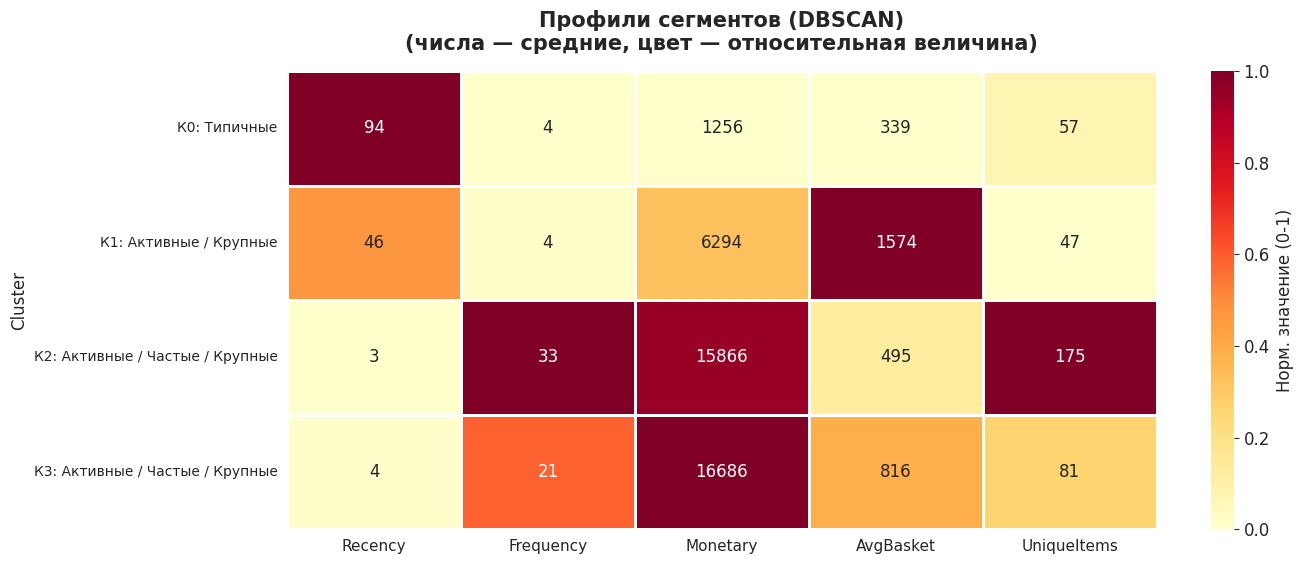

In [239]:
# Тепловая карта профилей победителя
cluster_ids = sorted([cl for cl in segment_names.keys() if cl != -1])

if len(cluster_ids) > 0:
    profile_cl = profile.loc[cluster_ids, feature_cols]
    profile_norm = (profile_cl - profile_cl.min()) / (profile_cl.max() - profile_cl.min() + 1e-10)
    row_labels = [f'К{cl}: {segment_names[cl]}' for cl in cluster_ids]

    fig, ax = plt.subplots(figsize=(14, max(len(cluster_ids) * 1.2 + 1, 4)))
    sns.heatmap(profile_norm, annot=profile_cl.values, fmt='.0f', cmap='YlOrRd',
                xticklabels=feature_cols, yticklabels=row_labels,
                linewidths=1, cbar_kws={'label': 'Норм. значение (0-1)'}, ax=ax)
    ax.set_title(f'Профили сегментов ({winner})\n(числа — средние, цвет — относительная величина)',
                 fontsize=15, fontweight='bold', pad=15)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()